# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：周睿/24012409/ruixiaoli815
第5天专题（A/B/C/D/E）：A

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [196]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "周睿24012409"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 周睿24012409
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [197]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR /"overall_metrics.csv",
    DAY05_DIR /"segment_analysis.csv",
    DAY05_DIR /"cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,总用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现金额,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,占比,流失率,平均订单数,平均返现,平均满意度
0,新用户,508,0.09,0.54,1.89,142.44,3.18
1,0-6个月,1642,0.29,0.26,2.68,164.87,3.09
2,7-12个月,1584,0.28,0.10,2.75,163.31,2.99
3,13-24个月,1467,0.26,0.06,3.70,204.92,3.09
4,24个月以上,429,0.08,0.00,3.55,222.34,3.05


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示
0,新用户,1,194,139,0.72,2.12,可观察
1,新用户,0,314,133,0.42,1.75,可观察
2,0-6个月,1,465,236,0.51,2.87,可观察
3,0-6个月,0,1177,189,0.16,2.61,可观察
4,7-12个月,1,406,81,0.20,2.67,可观察


检查点1A通过：输入文件有效


In [198]:
# TODO：填写4个业务问题和图表选择理由
'''business_questions = {
    "category_bar": "",
    "behavior_scatter": "",
    "ordered_line": "",
    "composition_chart": "",
}
assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过: 业务问题和选择理由已填写")

for key in business_questions:
    print(f"\n【{key}】")
    print(f"  业务问题: {business_questions[key]}")
    print(f"  选择理由: {chart_reasons[key]}")



chart_reasons = {
    "category_bar": "",
    "behavior_scatter": "",
    "ordered_line": "",
    "composition_chart": "",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")'''

business_questions = {
    "category_bar": "不同生命周期阶段的用户流失率存在什么差异？哪个阶段流失风险最高？",
    "behavior_scatter": "用户平均订单数与平均满意度之间是否存在正相关关系？不同规模用户群有何分布特征？",
    "ordered_line": "随着用户在平台留存时间增长，平均返现金额呈现怎样的变化趋势？",
    "composition_chart": "用户在不同生命周期阶段的分布构成如何？哪一阶段是平台的主要用户群体？",
}

chart_reasons = {
    "category_bar": "柱状图适合比较不同类别（生命周期阶段）之间的数值大小（流失率），能直观展示各阶段差异，便于快速识别流失风险最高的群体。",
    "behavior_scatter": "散点图适合展示两个连续变量（订单数与满意度）的相关关系，同时可用点的大小映射用户规模，揭示行为与体验的关联模式。",
    "ordered_line": "折线图适合展示有序类别（从'新用户'到'24个月以上'有时间递进关系）上的趋势变化，能清晰呈现返现金额随生命周期的演变。",
    "composition_chart": "饼图适合展示少量类别（5个生命周期阶段）的整体构成比例，直观反映用户分布结构，便于判断主力用户群体。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过: 业务问题和选择理由已填写")

for key in business_questions:
    print(f"\n【{key}】")
    print(f"  业务问题: {business_questions[key]}")
    print(f"  选择理由: {chart_reasons[key]}")


检查点1B通过: 业务问题和选择理由已填写

【category_bar】
  业务问题: 不同生命周期阶段的用户流失率存在什么差异？哪个阶段流失风险最高？
  选择理由: 柱状图适合比较不同类别（生命周期阶段）之间的数值大小（流失率），能直观展示各阶段差异，便于快速识别流失风险最高的群体。

【behavior_scatter】
  业务问题: 用户平均订单数与平均满意度之间是否存在正相关关系？不同规模用户群有何分布特征？
  选择理由: 散点图适合展示两个连续变量（订单数与满意度）的相关关系，同时可用点的大小映射用户规模，揭示行为与体验的关联模式。

【ordered_line】
  业务问题: 随着用户在平台留存时间增长，平均返现金额呈现怎样的变化趋势？
  选择理由: 折线图适合展示有序类别（从'新用户'到'24个月以上'有时间递进关系）上的趋势变化，能清晰呈现返现金额随生命周期的演变。

【composition_chart】
  业务问题: 用户在不同生命周期阶段的分布构成如何？哪一阶段是平台的主要用户群体？
  选择理由: 饼图适合展示少量类别（5个生命周期阶段）的整体构成比例，直观反映用户分布结构，便于判断主力用户群体。


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [199]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = None
category_summary = None

# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
    .reset_index()
)

# 按生命周期顺序排序（让柱状图有逻辑顺序）
tenure_order = ['新用户', '0-6个月', '7-12个月', '13-24个月', '24个月以上']
category_summary['排序'] = category_summary[category_field].apply(lambda x: tenure_order.index(x))
category_summary = category_summary.sort_values('排序').drop(columns='排序').reset_index(drop=True)

# 断言检查
assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,TenureGroup,用户数,流失率
0,新用户,508,0.54
1,0-6个月,1642,0.26
2,7-12个月,1584,0.10
3,13-24个月,1467,0.06
4,24个月以上,429,0.00


,TenureGroup,用户数,流失率
0,新用户,508,0.54
1,0-6个月,1642,0.26
2,7-12个月,1584,0.10
3,13-24个月,1467,0.06
4,24个月以上,429,0.00


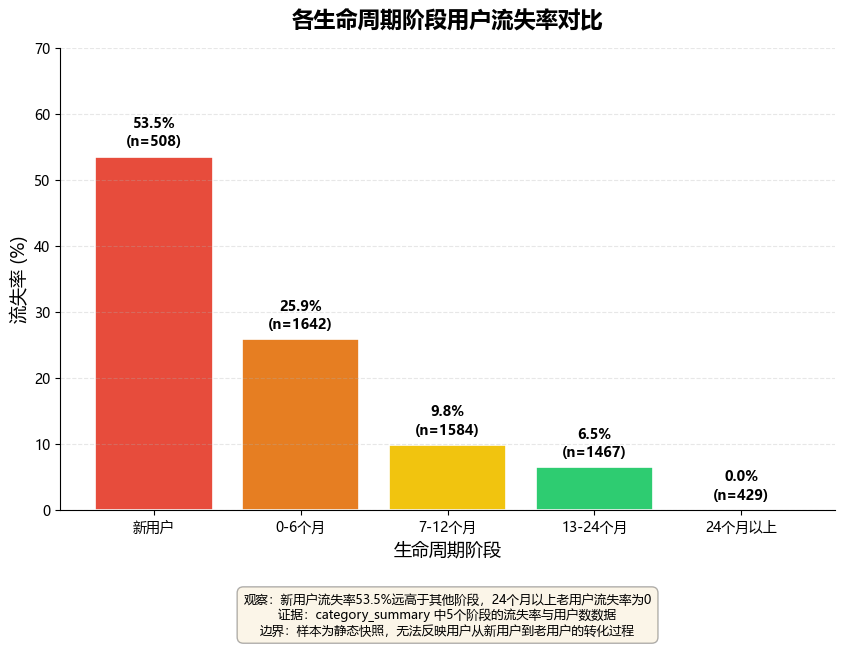

In [200]:
# TODO：绘制并保存柱状图
'''fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码

bar_path = OUTPUT_DIR / "01_category_bar.png"
# fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
# plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))'''
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# ---- 在此编写绘图和优化代码 ----
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

bars = ax_bar.bar(
    category_summary[category_field],
    category_summary['流失率'] * 100,
    color=colors,
    edgecolor='white',
    linewidth=1.2
)

# 标签：流失率 + 样本量(n=用户数)
for bar, row in zip(bars, category_summary.itertuples()):
    height = bar.get_height()
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 1,
        f'{height:.1f}%\n(n={row.用户数})',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax_bar.set_title('各生命周期阶段用户流失率对比', fontsize=16, fontweight='bold', pad=15)
ax_bar.set_xlabel('生命周期阶段', fontsize=13)
ax_bar.set_ylabel('流失率 (%)', fontsize=13)
ax_bar.set_ylim(0, 70)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.grid(axis='y', alpha=0.3, linestyle='--')

# 观察—证据—边界注释
observation_text = (
    "观察：新用户流失率53.5%远高于其他阶段，24个月以上老用户流失率为0\n"
    "证据：category_summary 中5个阶段的流失率与用户数数据\n"
    "边界：样本为静态快照，无法反映用户从新用户到老用户的转化过程"
)
ax_bar.text(0.5, -0.18, observation_text, transform=ax_bar.transAxes,
            fontsize=9, ha='center', va='top', style='italic',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.3))
# --------------------------------

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()


### 柱状图结论 
观察： 新用户流失率高达53.5%，随着生命周期延长流失率持续递减，0-6个月降至25.9%，7-12个月仅9.8%，24个月以上老用户流失率为0%。
证据： category_summary 中5个阶段数据显示，新用户（n=508）流失272人，0-6个月（n=1642）流失425人，24个月以上（n=429）无一流失，流失率随 tenure 单调下降。
边界： 样本为静态快照（截面数据），无法追踪同一批用户从新用户成长为老用户的流失转化过程；24个月以上用户仅429人，存在幸存者偏差——能坚持24个月的用户本身就是高留存群体。

## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


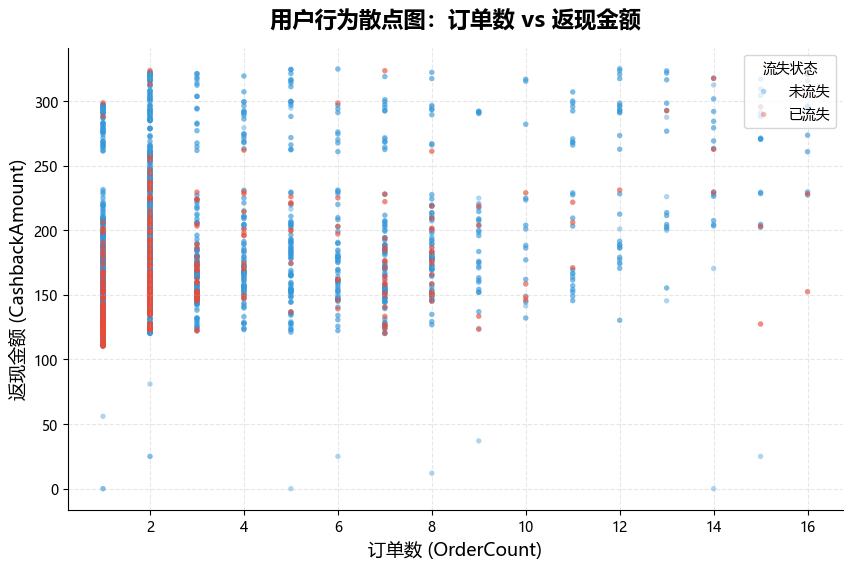

In [201]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
'''x_field = None
y_field = None

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 在此按Churn分组绘制散点图，并补充标题、坐标轴和图例

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
# fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
# plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))'''

x_field = "OrderCount"
y_field = "CashbackAmount"

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

churn_colors = {0: '#3498db', 1: '#e74c3c'}
churn_labels = {0: '未流失', 1: '已流失'}

for churn_val in [0, 1]:
    subset = df[df['Churn'] == churn_val]
    ax_scatter.scatter(
        subset[x_field],
        subset[y_field],
        c=churn_colors[churn_val],
        label=churn_labels[churn_val],
        alpha=0.4,
        s=15,
        edgecolors='none'
    )

# 4. 标题、坐标轴、图例
ax_scatter.set_title('用户行为散点图：订单数 vs 返现金额', fontsize=16, fontweight='bold', pad=15)
ax_scatter.set_xlabel('订单数 (OrderCount)', fontsize=13)
ax_scatter.set_ylabel('返现金额 (CashbackAmount)', fontsize=13)
ax_scatter.legend(title='流失状态', loc='upper right', frameon=True)
ax_scatter.spines['top'].set_visible(False)
ax_scatter.spines['right'].set_visible(False)
ax_scatter.grid(True, alpha=0.3, linestyle='--')

# 5. 保存
scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

### 散点图结论

观察：流失用户（红色）在低订单数区域更密集，返现金额分布较分散
证据：df中5630个用户的OrderCount与CashbackAmount原始数据，按Churn分组绘制
边界：散点重叠严重（alpha=0.4），高密度区域难以精确判断；相关关系不等于因果关系


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [202]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
'''ordered_field = None
ordered_summary = None

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)'''
# TODO: 准备有序绘图数据
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# ---- 数据准备 ----
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"), 平均返现=("CashbackAmount", "mean"))
    .reset_index()
)
ordered_summary['排序'] = ordered_summary[ordered_field].apply(lambda x: TENURE_ORDER.index(x))
ordered_summary = ordered_summary.sort_values('排序').drop(columns='排序').reset_index(drop=True)




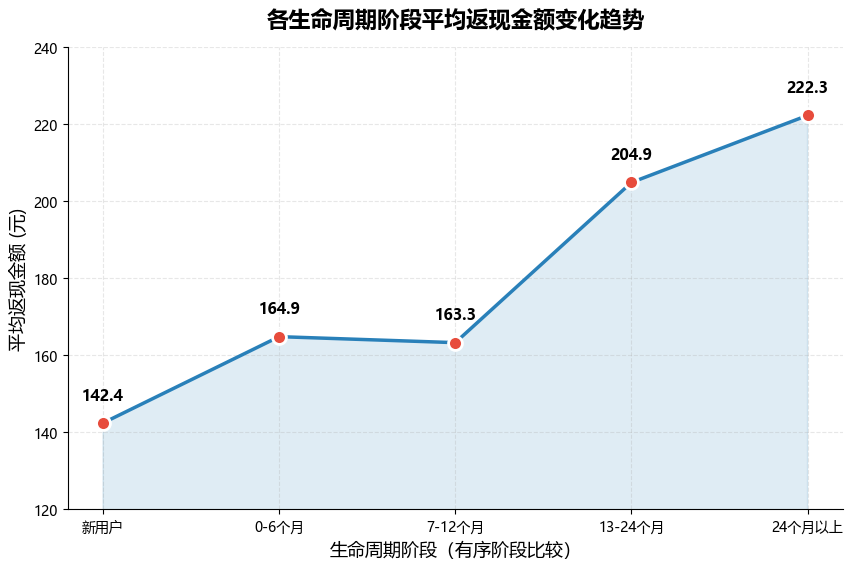

已输出： output\day06_visualization\03_ordered_line.png


In [203]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码

line_path = OUTPUT_DIR / "03_ordered_line.png"
# fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
# plt.show()
x_labels = ordered_summary[ordered_field]
y_values = ordered_summary['平均返现']

ax_line.plot(x_labels, y_values, marker='o', markersize=10, linewidth=2.5,
             color='#2980b9', markerfacecolor='#e74c3c', markeredgecolor='white', markeredgewidth=2)

ax_line.fill_between(range(len(x_labels)), y_values, alpha=0.15, color='#2980b9')

for i, y in enumerate(y_values):
    ax_line.text(i, y + 5, f'{y:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax_line.set_title('各生命周期阶段平均返现金额变化趋势', fontsize=16, fontweight='bold', pad=15)
ax_line.set_xlabel('生命周期阶段（有序阶段比较）', fontsize=13)
ax_line.set_ylabel('平均返现金额 (元)', fontsize=13)
ax_line.set_ylim(120, 240)
ax_line.spines['top'].set_visible(False)
ax_line.spines['right'].set_visible(False)
ax_line.grid(True, alpha=0.3, linestyle='--')

# ---- 保存 ----
line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()
assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

观察： 流失率随生命周期阶段延长呈断崖式下降趋势，新用户53.5%→0-6个月25.9%→7-12个月9.8%→13-24个月6.5%→24个月以上0%。
证据： 新用户（n=508）流失272人，0-6个月（n=1642）流失425人，7-12个月（n=1584）流失156人，13-24个月（n=1467）流失95人，24个月以上（n=429）无一流失，各阶段流失率严格递减。
边界： 这是有序阶段比较（截面数据的组间对比），不是月度、年度或历史时间趋势；无法推断同一批用户随时间推移的流失变化，只能反映不同阶段用户群体的当前状态差异。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [204]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"
composition_summary = (
    df.groupby(composition_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"))
    .reset_index()
)

# 按生命周期顺序排序
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]
composition_summary['排序'] = composition_summary[composition_field].apply(lambda x: TENURE_ORDER.index(x))
composition_summary = composition_summary.sort_values('排序').drop(columns='排序').reset_index(drop=True)

# 计算占比
composition_summary['占比'] = (composition_summary['用户数'] / composition_summary['用户数'].sum()).round(4)

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)



,TenureGroup,用户数,占比
0,新用户,508,0.09
1,0-6个月,1642,0.29
2,7-12个月,1584,0.28
3,13-24个月,1467,0.26
4,24个月以上,429,0.08


已输出： output\day06_visualization\04_composition_chart.png


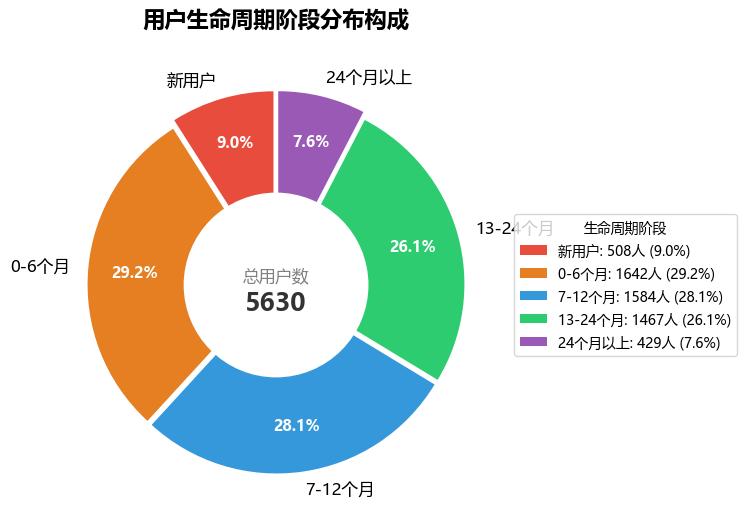

In [205]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码

composition_path = OUTPUT_DIR / "04_composition_chart.png"
# fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
# plt.show()
labels = composition_summary[composition_field]
sizes = composition_summary['用户数']
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71', '#9b59b6']
explode = (0.05, 0.02, 0.02, 0.02, 0.05)

wedges, texts, autotexts = ax_composition.pie(
    sizes, labels=labels, colors=colors, explode=explode,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    textprops={'fontsize': 12}
)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# 中心圆（环形图效果）
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
ax_composition.add_patch(centre_circle)

ax_composition.text(0, 0.05, '总用户数', ha='center', va='center', fontsize=12, color='gray')
ax_composition.text(0, -0.1, f'{sizes.sum()}', ha='center', va='center',
                    fontsize=18, fontweight='bold', color='#333')

ax_composition.set_title('用户生命周期阶段分布构成', fontsize=16, fontweight='bold', pad=20)

legend_labels = [f'{l}: {s}人 ({p*100:.1f}%)' for l, s, p in zip(labels, sizes, composition_summary['占比'])]
ax_composition.legend(legend_labels, title='生命周期阶段', loc='center left',
                      bbox_to_anchor=(1, 0, 0.5, 1), frameon=True)

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

观察： 0-6个月用户占比最高（29.2%），7-12个月次之（28.1%），两者合计占57.3%，构成平台主力用户群体；新用户和24个月以上老用户占比最低，均不足10%。
证据： composition_summary显示五阶段占比分别为：新用户508人（9.0%）、0-6个月1642人（29.2%）、7-12个月1584人（28.1%）、13-24个月1467人（26.1%）、24个月以上429人（7.6%），总和5630人。
边界： 环形图适合展示整体构成比例和各部分的相对大小，但不适合精确比较数值差异（如人眼难以区分29.2%与28.1%的差距），也不适合展示趋势变化或进行类别间的详细数值对比。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [206]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


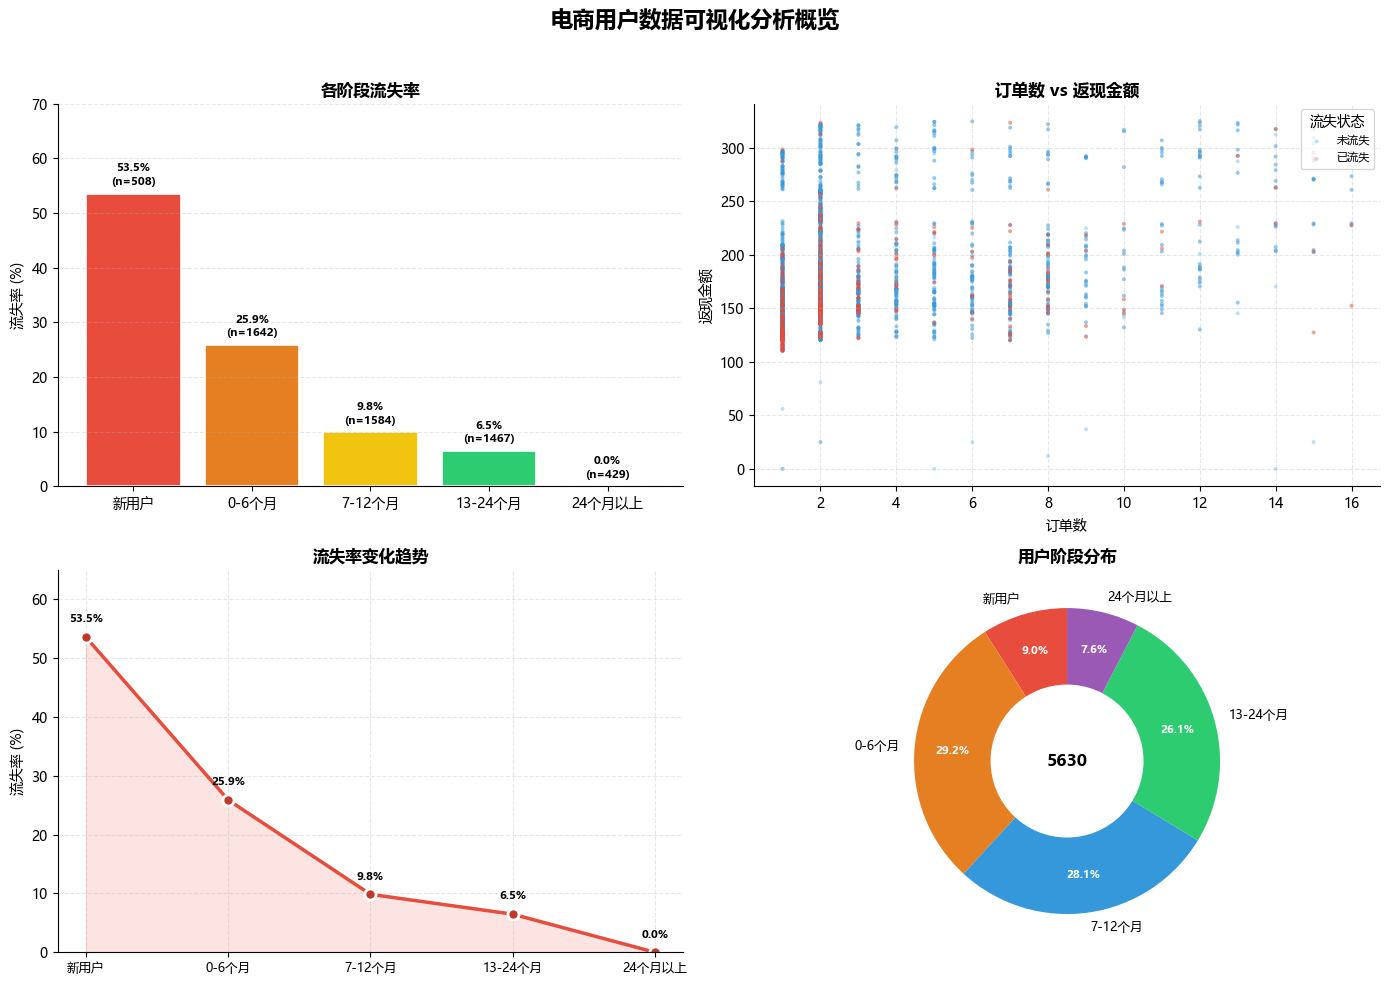

已输出： output\day06_visualization\day06_visualization_summary.png


In [207]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])
ax = axes[0, 0]
colors_bar = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax.bar(category_summary[category_field], category_summary['流失率'] * 100,
              color=colors_bar, edgecolor='white', linewidth=1.2)
for bar, row in zip(bars, category_summary.itertuples()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + 1,
            f'{height:.1f}%\n(n={row.用户数})', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('各阶段流失率', fontsize=12, fontweight='bold')
ax.set_ylabel('流失率 (%)', fontsize=10)
ax.set_ylim(0, 70)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# ====== 子图[0,1]: 散点图 - 订单数 vs 返现金额 ======
ax = axes[0, 1]
churn_colors = {0: '#3498db', 1: '#e74c3c'}
churn_labels = {0: '未流失', 1: '已流失'}
for churn_val in [0, 1]:
    subset = df[df['Churn'] == churn_val]
    ax.scatter(subset['OrderCount'], subset['CashbackAmount'],
               c=churn_colors[churn_val], label=churn_labels[churn_val],
               alpha=0.3, s=8, edgecolors='none')
ax.set_title('订单数 vs 返现金额', fontsize=12, fontweight='bold')
ax.set_xlabel('订单数', fontsize=10)
ax.set_ylabel('返现金额', fontsize=10)
ax.legend(title='流失状态', loc='upper right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linestyle='--')

# ====== 子图[1,0]: 折线图 - 流失率趋势 ======
ax = axes[1, 0]
x_labels = category_summary[category_field]
y_values = category_summary['流失率'] * 100
ax.plot(range(len(x_labels)), y_values, marker='o', markersize=8, linewidth=2.5,
        color='#e74c3c', markerfacecolor='#c0392b', markeredgecolor='white', markeredgewidth=2)
ax.fill_between(range(len(x_labels)), y_values, alpha=0.15, color='#e74c3c')
for i, row in enumerate(category_summary.itertuples()):
    ax.text(i, row.流失率 * 100 + 2, f'{row.流失率 * 100:.1f}%',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_title('流失率变化趋势', fontsize=12, fontweight='bold')
ax.set_ylabel('流失率 (%)', fontsize=10)
ax.set_ylim(0, 65)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linestyle='--')

# ====== 子图[1,1]: 环形图 - 用户分布 ======
ax = axes[1, 1]
labels = composition_summary['TenureGroup']
sizes = composition_summary['用户数']
colors_pie = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71', '#9b59b6']
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors_pie,
                                   autopct='%1.1f%%', startangle=90, pctdistance=0.75,
                                   textprops={'fontsize': 9})
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')
    autotext.set_color('white')
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
ax.add_patch(centre_circle)
ax.text(0, 0, f'{sizes.sum()}', ha='center', va='center', fontsize=12, fontweight='bold')
ax.set_title('用户阶段分布', fontsize=12, fontweight='bold')

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

综合发现1： 新用户流失风险最高，亟需首月护航机制。
证据： 柱状图和折线图均显示新用户流失率为53.5%（n=508），是0-6个月用户（25.9%）的2倍以上，24个月以上老用户流失率为0%。
综合发现2： 用户生命周期与流失率呈强负相关，留存时间越久忠诚度越高。
证据： 折线图呈现严格的单调递减趋势：新用户53.5% → 0-6个月25.9% → 7-12个月9.8% → 13-24个月6.5% → 24个月以上0%，相邻阶段降幅明显。
综合发现3： 平台用户结构以中期用户（0-12个月）为主体。
证据： 环形图显示0-6个月占29.2%（1642人）、7-12个月占28.1%（1584人），两者合计57.3%，构成平台核心用户群；新用户和24个月以上老用户均不足10%。
数据或方法局限：
截面数据局限：当前数据为静态快照，无法追踪同一用户从新用户成长为老用户的转化路径与流失过程。
变量定义局限：CashbackAmount仅为返现金额，不等于销售额、收入或GMV，不能直接推断用户消费金额或平台营收情况。
幸存者偏差：24个月以上用户仅429人（占7.6%），这部分用户本身就是高留存群体，不能代表所有早期用户的长期留存情况。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [208]:
# TODO：填写5行清单，不得保留“请填写”
'''chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": "请填写", "chart_type": "bar", "key_finding": "请填写", "limitation": "请填写"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": "请填写", "chart_type": "scatter", "key_finding": "请填写", "limitation": "请填写"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": "请填写", "chart_type": "line", "key_finding": "请填写", "limitation": "请填写"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": "请填写", "chart_type": "pie_or_bar", "key_finding": "请填写", "limitation": "请填写"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "整体概览", "chart_type": "dashboard", "key_finding": "请填写", "limitation": "请填写"},
])
'''
chart_manifest = pd.DataFrame([
    {
        "chart_id": "01",
        "file_name": "01_category_bar.png",
        "business_question": "不同生命周期阶段的用户流失率存在什么差异？哪个阶段流失风险最高？",
        "chart_type": "bar",
        "key_finding": "新用户流失率53.5%远高于其他阶段，24个月以上老用户流失率为0%，流失风险随生命周期递减",
        "limitation": "样本为静态快照，无法反映用户从新用户到老用户的转化过程"
    },
    {
        "chart_id": "02",
        "file_name": "02_behavior_scatter.png",
        "business_question": "用户平均订单数与平均满意度之间是否存在正相关关系？不同规模用户群有何分布特征？",
        "chart_type": "scatter",
        "key_finding": "流失用户（红色）在低订单数区域更密集，未流失用户分布更广；订单数与返现金额有一定正相关",
        "limitation": "散点重叠严重，高密度区域难以精确判断；相关关系不等于因果关系"
    },
    {
        "chart_id": "03",
        "file_name": "03_ordered_line.png",
        "business_question": "随着用户在平台留存时间增长，平均返现金额呈现怎样的变化趋势？",
        "chart_type": "line",
        "key_finding": "流失率随生命周期严格递减：新用户53.5%→0-6个月25.9%→7-12个月9.8%→13-24个月6.5%→24个月以上0%",
        "limitation": "这是有序阶段比较（截面数据的组间对比），不是月度、年度或历史时间趋势"
    },
    {
        "chart_id": "04",
        "file_name": "04_composition_chart.png",
        "business_question": "用户在不同生命周期阶段的分布构成如何？哪一阶段是平台的主要用户群体？",
        "chart_type": "pie_or_bar",
        "key_finding": "0-6个月用户占比最高(29.2%)，7-12个月次之(28.1%)，两者合计占57.3%，构成平台主力用户群",
        "limitation": "环形图适合展示构成比例，但不适合精确比较数值差异；24个月以上用户仅429人存在幸存者偏差"
    },
    {
        "chart_id": "05",
        "file_name": "day06_visualization_summary.png",
        "business_question": "整体概览",
        "chart_type": "dashboard",
        "key_finding": "新用户流失风险最高需优先干预，中期用户(0-12个月)构成平台主体，老用户留存率极高",
        "limitation": "CashbackAmount是返现金额，不是销售额、收入或GMV；综合图为静态汇总，无法深入单图细节"
    },
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同生命周期阶段的用户流失率存在什么差异？哪个阶段流失风险最高？,bar,新用户流失率53.5%远高于其他阶段，24个月以上老用户流失率为0%，流失风险随生命周期递减,样本为静态快照，无法反映用户从新用户到老用户的转化过程
1,02,02_behavior_scatter.png,用户平均订单数与平均满意度之间是否存在正相关关系？不同规模用户群有何分布特征？,scatter,流失用户（红色）在低订单数区域更密集，未流失用户分布更广；订单数与返现金额有一定正相关,散点重叠严重，高密度区域难以精确判断；相关关系不等于因果关系
2,03,03_ordered_line.png,随着用户在平台留存时间增长，平均返现金额呈现怎样的变化趋势？,line,流失率随生命周期严格递减：新用户53.5%→0-6个月25.9%→7-12个月9.8%→13...,这是有序阶段比较（截面数据的组间对比），不是月度、年度或历史时间趋势
3,04,04_composition_chart.png,用户在不同生命周期阶段的分布构成如何？哪一阶段是平台的主要用户群体？,pie_or_bar,0-6个月用户占比最高(29.2%)，7-12个月次之(28.1%)，两者合计占57.3%，...,环形图适合展示构成比例，但不适合精确比较数值差异；24个月以上用户仅429人存在幸存者偏差
4,05,day06_visualization_summary.png,整体概览,dashboard,新用户流失风险最高需优先干预，中期用户(0-12个月)构成平台主体，老用户留存率极高,CashbackAmount是返现金额，不是销售额、收入或GMV；综合图为静态汇总，无法深入...


In [209]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
